In [1]:
import pandas as pd 
import numpy as np

ModuleNotFoundError: No module named 'pandas'

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
df = pd.read_csv(rf"E:\AIML_apna_college\07_Pytorch_DL\datasets\powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
'''AT => temperature 
V => vaccum 
AP = > pressure 
RH = > humidity '''

'AT => temperature \nV => vaccum \nAP = > pressure \nRH = > humidity '

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE",axis=1)
y = df["PE"]


Convert the dataset of Tensor 

In [7]:
# Split 
from sklearn.model_selection import  train_test_split

X_train , X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2 ,random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [9]:
import torch 
import torch.nn as nn


In [10]:
type(X_train_scaled)  # numpy.ndarray
type(y_test) #pandas.core.frame.DataFrame

# the dtype of y_test is different so use the ".values" 

pandas.core.series.Series

In [11]:
y_test.shape # (1914,)

# the shape is (n,0) so we convert it onto (n, 1) 
# we use the .view(n,1) ==> (.view(-1,1))  [-1] ==> for all

(1914,)

In [12]:
X_train_tensor = torch.tensor(X_train_scaled,dtype =torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype =torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype =torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype =torch.float32).view(-1,1)


In [13]:
from torch.utils.data import TensorDataset, DataLoader

# TensorDataset is used to combine feature tensors (X) and label tensors (y) into one dataset object.
# This keeps input-target pairs aligned by index, so each sample and its correct label are returned together.
#
# DataLoader is used to iterate over that dataset efficiently in mini-batches during training/testing.
# It can also shuffle data (for better training generalization) and handles batching automatically.
#
# Relation:
# TensorDataset = "what data is" (samples + labels)
# DataLoader   = "how data is fed" (batching, shuffling, iteration)

In [14]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [15]:
# create dataload 

train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
test_loader =DataLoader(test_dataset,batch_size=32)

Model buiding

In [16]:
# deep learning

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # first layer
            nn.Linear(X_train.shape[1], 6),  # in_features=4, out_features=6
            nn.ReLU(),

            # second layer
            nn.Linear(6, 6),  # in_features=6, out_features=6
            nn.ReLU(),

            # output
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)


In [20]:
import torch.optim as optim
model = ANN()

# loss , optimizer

crieteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

training ANN


In [21]:
# 100 - epochs 
# multiple batches
train_loss = []
valid_loss = []
num_epochs = 100 
for epoch in range(num_epochs):
    model.train()   # there are various of model of models 
    running_loss = 0.0  # total training loss for 1 epoch
    for xb, yb in train_loader:
        # xb = feature of 1 batches 
        # yb = label of 1 batches
        optimizer.zero_grad()
        output = model(xb) # predicated output batch

        # loss 
        loss = crieteria(output,yb)
        loss.backward() # back propagation
        optimizer.step() # update 

        running_loss += loss.item() # loss is tensor so , tensor -> py float
    epoch_training_loss = running_loss/len(train_loader)
    train_loss.append(epoch_training_loss)


    model.eval()
    # validation 
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            # xb = feature of 1 batches 
            # yb = label of 1 batches
            output = model(xb) # predicated output batch

            # loss 
            loss = crieteria(output,yb)
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    valid_loss.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{num_epochs} ==> train loss = {epoch_training_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 206740.3998046875 & val loss = 205894.84348958332
epoch 2/100 ==> train loss = 204350.20481770832 & val loss = 201532.29140625
epoch 3/100 ==> train loss = 196758.67975260416 & val loss = 190030.07682291666
epoch 4/100 ==> train loss = 180959.818359375 & val loss = 169859.70494791667
epoch 5/100 ==> train loss = 156729.28219401042 & val loss = 142026.60807291666
epoch 6/100 ==> train loss = 126412.23912760416 & val loss = 109997.17421875
epoch 7/100 ==> train loss = 94297.29697265624 & val loss = 78886.06692708333
epoch 8/100 ==> train loss = 65571.6837890625 & val loss = 53426.10631510417
epoch 9/100 ==> train loss = 44086.660400390625 & val loss = 36296.95804036458
epoch 10/100 ==> train loss = 30826.570194498698 & val loss = 26680.55087890625
epoch 11/100 ==> train loss = 23833.090763346354 & val loss = 21757.425911458333
epoch 12/100 ==> train loss = 20174.538118489585 & val loss = 18890.65205078125
epoch 13/100 ==> train loss = 17704.07018432617 & val 

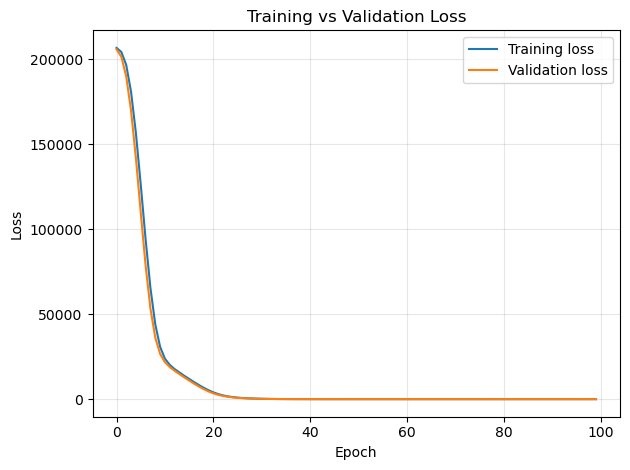

In [22]:
import matplotlib.pyplot as plt 

loss_df = pd.DataFrame({
    "training_loss" :train_loss,
    "validation_loss" : valid_loss 
})

plt.plot(loss_df["training_loss"],label ="Training loss")
plt.plot(loss_df["validation_loss"],label ="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

loading and save the best model

In [27]:
# 100 - epochs 
# multiple batches
train_loss = []
valid_loss = []
best_model = float("inf")
num_epochs = 100 
for epoch in range(num_epochs):
    model.train()   # there are various of model of models 
    running_loss = 0.0  # total training loss for 1 epoch
    for xb, yb in train_loader:
        # xb = feature of 1 batches 
        # yb = label of 1 batches
        optimizer.zero_grad()
        output = model(xb) # predicated output batch

        # loss 
        loss = crieteria(output,yb)
        loss.backward() # back propagation
        optimizer.step() # update 

        running_loss += loss.item() # loss is tensor so , tensor -> py float
    epoch_training_loss = running_loss/len(train_loader)
    train_loss.append(epoch_training_loss)
    


    model.eval()
    # validation 
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            # xb = feature of 1 batches 
            # yb = label of 1 batches
            output = model(xb) # predicated output batch

            # loss 
            loss = crieteria(output,yb)
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    valid_loss.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{num_epochs} ==> train loss = {epoch_training_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_model:
        best_model = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")




epoch 1/100 ==> train loss = 20.76049650112788 & val loss = 18.917880590756734
epoch 2/100 ==> train loss = 20.847113196055094 & val loss = 19.06357571283976
epoch 3/100 ==> train loss = 20.796515595912933 & val loss = 19.24936931927999
epoch 4/100 ==> train loss = 20.727827509244282 & val loss = 18.977072763442994
epoch 5/100 ==> train loss = 20.845489760239918 & val loss = 18.974405018488564
epoch 6/100 ==> train loss = 20.755137777328493 & val loss = 19.02695418993632
epoch 7/100 ==> train loss = 20.77259332338969 & val loss = 19.056450239817302
epoch 8/100 ==> train loss = 20.756487385431925 & val loss = 19.043318088849386
epoch 9/100 ==> train loss = 20.724666398763656 & val loss = 19.139000860850015
epoch 10/100 ==> train loss = 20.863540597756703 & val loss = 18.9686691681544
epoch 11/100 ==> train loss = 20.75529223481814 & val loss = 19.017293492952984
epoch 12/100 ==> train loss = 20.740419691801073 & val loss = 19.032473301887514
epoch 13/100 ==> train loss = 20.759889471530

In [28]:
model.load_state_dict(torch.load("best_model.pt", weights_only=False))

<All keys matched successfully>